# backbone_transformer: overnight overfitting/underfitting sweep

Six new hyperparameter combinations for `backbone_transformer`, each testing a
different, previously untried lever against overfitting (or, where a lever can
overshoot, against underfitting too). None of these repeat a combination already
tried in the main notebook's ablation (section 17 there): unfreezing 2 stages,
a smaller Transformer (`B4`: 2 layers, d_model 128), and a longer frozen warmup
with higher weight decay were all tried already and none of them helped, so this
sweep tries different axes, and where it revisits an axis (`C6`, capacity) it goes
further than what was already tried rather than repeating it.

## Before running this notebook

Two of the levers below (`C1`, `C4`, `C5`) use a new config option,
`freeze_bn_stats_after_unfreeze`, that does not exist in the project yet. Apply
this small patch to your local clone first (3 files, about 15 lines total):

1. `config/config.py`, in `ModelConfig`, right after `transformer_dropout`:
   ```python
   # Keeps BatchNorm running mean/var frozen at their pretrained values even after
   # unfreeze_last_stages() makes the conv weights trainable again. The BN affine
   # weight/bias still receive gradients; only the running statistics stay fixed.
   freeze_bn_stats_after_unfreeze: bool = False
   ```
2. `models/backbone_transformer.py`, replace `unfreeze_last_stages`:
   ```python
   def unfreeze_last_stages(self, num_stages: int = 2, freeze_bn_stats: bool = False) -> None:
       """Unfreezes `layer4` (num_stages=1) or `layer3` + `layer4` (num_stages=2)
       for a second fine-tuning phase with a lower learning rate.

       `freeze_bn_stats`: when True, the BatchNorm layers inside the newly
       unfrozen stages stay pinned in eval mode (like the still-frozen stages),
       so their running mean/var keep the ImageNet statistics instead of being
       updated from small fine-tuning batches. Their affine weight/bias still
       get gradients and are still trained, since only `requires_grad` controls
       that, not train/eval mode. When False (default), behaviour is unchanged
       from before this option existed.
       """

       if self._backbone_unfrozen:
           return
       stage_indices = {1: [7], 2: [6, 7]}.get(num_stages)
       if stage_indices is None:
           raise ValueError("num_stages must be 1 or 2.")

       for stage_index in stage_indices:
           stage_module = self.backbone[stage_index]
           for parameter in stage_module.parameters():
               parameter.requires_grad = True
           if not freeze_bn_stats:
               stage_bn_modules = [m for m in stage_module.modules() if isinstance(m, nn.BatchNorm2d)]
               self._frozen_bn_modules = [m for m in self._frozen_bn_modules if m not in stage_bn_modules]
       self._backbone_unfrozen = True
   ```
3. `training/trainer.py`, in `_maybe_unfreeze_backbone`, replace the single call:
   ```python
   self.model.unfreeze_last_stages(
       self.config.model.unfreeze_num_stages,
       freeze_bn_stats=self.config.model.freeze_bn_stats_after_unfreeze,
   )
   ```

`C2` and `C3` only use `data.val_ratio` and `training.loss`/`focal_gamma`/`focal_alpha`,
which already exist in `config/config.py`, no patch needed for those two.

## The six combinations

All six start from the current final `backbone_transformer` setup (`B3`/`run1b`:
8 frozen epochs, `layer4` only, backbone lr 5e-6, weight decay 5e-4, dropout
0.3/0.4, batch 15, ROC-AUC monitor) and change only what is listed:

- **C1, BN stats frozen after unfreeze.** Isolates the one change proposed in the
  main notebook's Future Work but never tested: `freeze_bn_stats_after_unfreeze = True`.
  With batch size 15, `layer4`'s running mean/var get noisy small-batch estimates
  once unfrozen; this removes that noise source while still letting `layer4` adapt
  (its weights and BN affine parameters keep training normally).
- **C2, larger internal validation split.** `val_ratio = 0.2` instead of 0.1 (roughly
  320 validation clips instead of 160). The main notebook's own Limitations section
  names the small validation split as the main source of noisy "best epoch"
  selection; a bigger split gives early stopping and checkpoint selection a more
  reliable signal, which fights both an unlucky early stop (underfitting) and a
  late one (overfitting past the real optimum).
- **C3, focal loss instead of BCE.** `loss = "focal"` (gamma 2.0, alpha 0.25), everything
  else at the `B3` values. Every previous ablation varied architecture, learning
  rate, dropout or weight decay; none changed the loss function itself. Focal loss
  down-weights clips the model already classifies confidently, so late-training
  gradient stays concentrated on the hard/ambiguous clips instead of continuing to
  fit easy ones past the point that helps.
- **C4, shorter patience + BN stats frozen.** `early_stopping_patience = 4` (down from
  8) stacked with `C1`'s BN freeze. Stops closer to the true peak instead of riding
  out up to 8 more epochs of drift after it, combined with one less source of
  instability in the unfrozen stage.
- **C5, stronger regularisation + BN stats frozen.** Weight decay raised to 1e-3
  (`B3` uses 5e-4; the one prior attempt at changing it, `B5`, actually *lowered*
  it to 1e-4 and that made things worse) and the backbone learning rate lowered to
  2e-6 (from 5e-6), stacked with the BN freeze. The most conservative fine-tuning
  setting tried yet. If this one clearly underperforms on validation too (not just
  test), that is itself informative: it would mean `B3` was already close to the
  right amount of regularisation, and pushing further costs accuracy without
  buying stability (i.e. this config would be underfitting).
- **C6, smaller Transformer, everything else at `B3`.** `n_layers = 1`, `d_model = 64`,
  `n_heads = 4`, `ff_dim = 256` (`B4` used 2 layers / d_model 128 and did not help,
  but `B4` also changed `freeze_backbone_epochs` to 10 and `backbone_learning_rate`
  to 1e-6 at the same time, so it never isolated capacity on its own). `C6` goes
  smaller than `B4` and changes nothing else from `B3` (still 8 frozen epochs,
  backbone lr 5e-6, weight decay 5e-4, dropout 0.3/0.4), so if it still does not
  help, that is a cleaner result: it would mean Transformer capacity specifically
  is not the lever for this overfitting, not just that `B4`'s particular
  combination wasn't the right one.

## How this notebook runs overnight, unattended

- Configs train **one at a time**, in order. Each one is skipped (not retrained) if
  it already has a checkpoint or history file, exactly like the main notebook, so
  a rerun after an interruption picks up where it left off instead of starting over.
- `num_epochs = 20` and default `early_stopping_patience = 6` (except `C4`, which
  tests `patience = 4` on purpose) for all six, shorter than `B3`'s 25/8. The
  original ablation runs already show overfitting setting in around epoch 16, so
  20 epochs is enough to see the full pattern without spending the whole night on
  epochs past the point these comparisons need. Lower `MAX_EPOCHS` below if you
  need every run to finish faster.
- If you stop the kernel or it errors out mid-run, whatever finished is safe on
  disk (`checkpoints/<name>/`, `logs/<name>/`); rerun the training cell later and
  it continues from the next un-started config.

## 1. Project setup

Same project-root discovery as the main notebook: looks for `config/config.py` in
the current or parent directory (the normal case when running this locally, from
inside the cloned project), and clones from GitHub only as a fallback.

In [28]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
GITHUB_REPO_URL = "https://github.com/26leonardo/Violence-detection.git"
DATA_ROOT = "./data/RWF-2000"
PROJECT_ROOT_OVERRIDE = None  # e.g. "/home/me/violence_detection"


def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    if IN_COLAB:
        candidates.append(Path("/content/violence_detection"))
    for candidate in candidates:
        if (candidate / "config" / "config.py").exists():
            return candidate.resolve()
    if PROJECT_ROOT_OVERRIDE is not None:
        return Path(PROJECT_ROOT_OVERRIDE).resolve()
    raise FileNotFoundError(
        "Could not find the project root (a folder containing config/config.py). "
        "Open this notebook from inside the project (or its notebooks/ folder), "
        "or set PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /home/pp26/violence_detection/violence_detection


## 2. Imports

Checks that `freeze_bn_stats_after_unfreeze` (the patch from section 0) is present
before doing anything else, since `C1`, `C4` and `C5` depend on it and a silent
`TypeError` partway through an overnight run is exactly what this check avoids.

In [29]:
import gc
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import precision_recall_curve, roc_curve

from config.config import Config, ModelConfig, get_default_config
from data.dataloaders import build_dataloaders
from evaluate import run_inference
from models.build import build_model
from training.metrics import compute_binary_metrics, compute_confusion_matrix, find_threshold_for_recall
from training.trainer import Trainer
from utils.checkpoint import load_checkpoint
from utils.device import get_device
from utils.history import plot_comparison, plot_training_curves
from utils.seed import set_seed

if "freeze_bn_stats_after_unfreeze" not in ModelConfig.__dataclass_fields__:
    raise AttributeError(
        "ModelConfig has no 'freeze_bn_stats_after_unfreeze' field. Apply the patch described in "
        "section 0 to config/config.py, models/backbone_transformer.py and training/trainer.py first."
    )

device = get_device()
print("Device:", device)

SEED = 42
set_seed(SEED)

HISTORY_LOG_DIR = "./logs"
CHECKPOINT_DIR = "./checkpoints"
BASELINE_RUN_NAME = "backbone_transformer_run1b"  # the already-trained B3 / final run, used as reference only


def read_history_file(path):
    """Reads one history.jsonl file and returns one dict per epoch."""
    with open(path) as history_file:
        records = [json.loads(line) for line in history_file if line.strip()]
    if not records:
        raise ValueError(f"{path} contains no records")
    last_run_start = 0
    for index in range(1, len(records)):
        if records[index]["epoch"] <= records[index - 1]["epoch"]:
            last_run_start = index
    return records[last_run_start:]

Device: cuda


## 3. The six configurations

Each function edits a fresh `get_default_config("backbone_transformer")`. Only
the values called out in section 0 differ from `B3`; everything else (data
resolution, Transformer size, classifier dropout, optimiser, warmup) stays at
the `B3` values so each config isolates its own change.

In [30]:
MAX_EPOCHS = 20


def base_backbone_config(run_config):
    run_config.data.num_frames = 16
    run_config.data.frame_size = 224
    run_config.data.num_workers = 0
    run_config.model.pretrained = True
    run_config.model.transformer_dropout = 0.3
    run_config.model.classifier_dropout = 0.4
    run_config.model.freeze_backbone_epochs = 8
    run_config.model.unfreeze_num_stages = 1
    run_config.training.optimizer = "adamw"
    run_config.training.learning_rate = 1e-4
    run_config.training.backbone_learning_rate = 5e-6
    run_config.training.weight_decay = 5e-4
    run_config.training.warmup_ratio = 0.05
    run_config.training.batch_size = 15
    run_config.training.num_epochs = MAX_EPOCHS
    run_config.training.monitor_metric = "roc_auc"
    run_config.training.early_stopping_patience = 6


def base_c9_config(run_config):
    base_backbone_config(run_config)
    run_config.model.n_layers = 1
    run_config.model.d_model = 64
    run_config.model.n_heads = 4
    run_config.model.ff_dim = 256
    run_config.model.transformer_dropout = 0.5
    run_config.model.classifier_dropout = 0.6
    run_config.model.freeze_bn_stats_after_unfreeze = True


def configure_c16_c11_more_capacity(run_config):
    """C11 (C9 + 8 frames) was the new best. Tests whether the capacity cut
    (d_model=64) is still a bottleneck once the input itself is smaller, or
    whether 8 frames alone was already the fix and more width reopens the gap.
    """
    base_c9_config(run_config)
    run_config.data.num_frames = 8
    run_config.model.d_model = 96
    run_config.model.ff_dim = 384


def configure_c17_c11_interpolate_frames(run_config):
    """C11 used 8 frames, C9 used 16. Tests the midpoint to see if 8 was
    the actual sweet spot or just the first value tried.
    """
    base_c9_config(run_config)
    run_config.data.num_frames = 12


def configure_c18_c14_partial_unfreeze(run_config):
    """C14 (frozen backbone + 8 frames) looked mildly underfit, lowest test
    score of the healthy-gap group. Keeps the 8-frame cut but lets the
    backbone unfreeze partway through instead of staying frozen the whole
    run, to see if a little fine-tuning capacity recovers performance
    without reopening the train-val gap.
    """
    base_c9_config(run_config)
    run_config.data.num_frames = 8
    run_config.model.freeze_backbone_epochs = 12
    run_config.model.freeze_bn_stats_after_unfreeze = True


EXPERIMENTS = [
    ("backbone_c16_c11_more_capacity", configure_c16_c11_more_capacity),
    ("backbone_c17_c11_interpolate_frames", configure_c17_c11_interpolate_frames),
    ("backbone_c18_c14_partial_unfreeze", configure_c18_c14_partial_unfreeze),
]


def build_experiment_config(name, configure_fn):
    run_config = get_default_config("backbone_transformer")
    run_config.paths.experiment_name = name
    run_config.data.data_root = DATA_ROOT
    run_config.training.seed = SEED
    configure_fn(run_config)
    return run_config


experiment_configs = {name: build_experiment_config(name, configure_fn) for name, configure_fn in EXPERIMENTS}

rows = []
for name, config in experiment_configs.items():
    rows.append({
        "name": name,
        "num_frames": config.data.num_frames,
        "frame_size": config.data.frame_size,
        "n_layers": config.model.n_layers,
        "d_model": config.model.d_model,
        "n_heads": config.model.n_heads,
        "ff_dim": config.model.ff_dim,
        "freeze_backbone_epochs": config.model.freeze_backbone_epochs,
        "freeze_bn_stats": config.model.freeze_bn_stats_after_unfreeze,
    })
display(pd.DataFrame(rows).set_index("name"))

,num_frames,frame_size,n_layers,d_model,n_heads,ff_dim,freeze_backbone_epochs,freeze_bn_stats
name,,,,,,,,
backbone_c16_c11_more_capacity,8,224,1,96,4,384,8,True
backbone_c17_c11_interpolate_frames,12,224,1,64,4,256,8,True
backbone_c18_c14_partial_unfreeze,8,224,1,64,4,256,12,True


In [31]:
# MAX_EPOCHS = 20


# def base_backbone_config(run_config):
#     run_config.data.num_frames = 16
#     run_config.data.frame_size = 224
#     run_config.data.num_workers = 0
#     run_config.model.pretrained = True
#     run_config.model.transformer_dropout = 0.3
#     run_config.model.classifier_dropout = 0.4
#     run_config.model.freeze_backbone_epochs = 8
#     run_config.model.unfreeze_num_stages = 1
#     run_config.training.optimizer = "adamw"
#     run_config.training.learning_rate = 1e-4
#     run_config.training.backbone_learning_rate = 5e-6
#     run_config.training.weight_decay = 5e-4
#     run_config.training.warmup_ratio = 0.05
#     run_config.training.batch_size = 15
#     run_config.training.num_epochs = MAX_EPOCHS
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.early_stopping_patience = 6


# def base_c9_config(run_config):
#     """C9 lineage: unfrozen backbone, current best generalizer. Starting point
#     for narrower/shorter/lower-res variants below."""
#     base_backbone_config(run_config)
#     run_config.model.n_layers = 1
#     run_config.model.d_model = 64
#     run_config.model.n_heads = 4
#     run_config.model.ff_dim = 256
#     run_config.model.transformer_dropout = 0.5
#     run_config.model.classifier_dropout = 0.6
#     run_config.model.freeze_bn_stats_after_unfreeze = True


# def base_c7_config(run_config):
#     """C7 lineage: backbone frozen for the whole run, cleanest val-test gap
#     but lower ceiling."""
#     base_backbone_config(run_config)
#     run_config.model.n_layers = 1
#     run_config.model.d_model = 64
#     run_config.model.n_heads = 4
#     run_config.model.ff_dim = 256
#     run_config.model.freeze_backbone_epochs = MAX_EPOCHS


# def configure_c10_c9_narrower(run_config):
#     base_c9_config(run_config)
#     run_config.model.d_model = 32
#     run_config.model.n_heads = 2
#     run_config.model.ff_dim = 128


# def configure_c11_c9_fewer_frames(run_config):
#     base_c9_config(run_config)
#     run_config.data.num_frames = 8


# def configure_c12_c9_lower_res(run_config):
#     base_c9_config(run_config)
#     run_config.data.frame_size = 160


# def configure_c13_c7_narrower(run_config):
#     base_c7_config(run_config)
#     run_config.model.d_model = 32
#     run_config.model.n_heads = 2
#     run_config.model.ff_dim = 128


# def configure_c14_c7_fewer_frames(run_config):
#     base_c7_config(run_config)
#     run_config.data.num_frames = 8


# def configure_c15_c7_lower_res(run_config):
#     base_c7_config(run_config)
#     run_config.data.frame_size = 160


# EXPERIMENTS = [
#     ("backbone_c10_c9_narrower", configure_c10_c9_narrower),
#     ("backbone_c11_c9_fewer_frames", configure_c11_c9_fewer_frames),
#     ("backbone_c12_c9_lower_res", configure_c12_c9_lower_res),
#     ("backbone_c13_c7_narrower", configure_c13_c7_narrower),
#     ("backbone_c14_c7_fewer_frames", configure_c14_c7_fewer_frames),
#     ("backbone_c15_c7_lower_res", configure_c15_c7_lower_res),
# ]


# def build_experiment_config(name, configure_fn):
#     run_config = get_default_config("backbone_transformer")
#     run_config.paths.experiment_name = name
#     run_config.data.data_root = DATA_ROOT
#     run_config.training.seed = SEED
#     configure_fn(run_config)
#     return run_config


# experiment_configs = {name: build_experiment_config(name, configure_fn) for name, configure_fn in EXPERIMENTS}

# rows = []
# for name, config in experiment_configs.items():
#     rows.append({
#         "name": name,
#         "num_frames": config.data.num_frames,
#         "frame_size": config.data.frame_size,
#         "n_layers": config.model.n_layers,
#         "d_model": config.model.d_model,
#         "n_heads": config.model.n_heads,
#         "ff_dim": config.model.ff_dim,
#         "freeze_backbone_epochs": config.model.freeze_backbone_epochs,
#         "freeze_bn_stats": config.model.freeze_bn_stats_after_unfreeze,
#     })
# display(pd.DataFrame(rows).set_index("name"))

In [32]:
# MAX_EPOCHS = 20  # shorter than B3's 25; lower this further if the night is short


# def base_backbone_config(run_config):
#     """Applies the B3 / run1b baseline values every config below starts from."""
#     run_config.data.num_frames = 16
#     run_config.data.frame_size = 224
#     run_config.data.num_workers = 0
#     run_config.model.pretrained = True
#     run_config.model.transformer_dropout = 0.3
#     run_config.model.classifier_dropout = 0.4
#     run_config.model.freeze_backbone_epochs = 8
#     run_config.model.unfreeze_num_stages = 1
#     run_config.training.optimizer = "adamw"
#     run_config.training.learning_rate = 1e-4
#     run_config.training.backbone_learning_rate = 5e-6
#     run_config.training.weight_decay = 5e-4
#     run_config.training.warmup_ratio = 0.05
#     run_config.training.batch_size = 15
#     run_config.training.num_epochs = MAX_EPOCHS
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.early_stopping_patience = 6


# def base_c6_config(run_config):
#     """C6's winning capacity reduction on top of the B3 baseline. Every config
#     below starts here: C6 was the only config in the first batch whose val_loss
#     curve actually stayed flat instead of blowing up after its peak, so it is
#     the real baseline to build on now, not B3.
#     """
#     base_backbone_config(run_config)
#     run_config.model.n_layers = 1
#     run_config.model.d_model = 64
#     run_config.model.n_heads = 4
#     run_config.model.ff_dim = 256


# def configure_c8_c6_more_capacity(run_config):
#     """C8: adds capacity back toward B4's size (2 layers, d_model 128), but
#     unlike B4 keeps every other hyperparameter at C6/B3's values (8 frozen
#     epochs, backbone lr 5e-6). B4 never isolated capacity cleanly since it also
#     changed those two; this does. Tests whether C6's val_loss curve still holds
#     flat with more room, or whether 1 layer / d_model 64 is closer to the real
#     ceiling than a comfortable margin.
#     """
#     base_c6_config(run_config)
#     run_config.model.n_layers = 2       # C6 used 1, B4 used 2, default is 4
#     run_config.model.d_model = 128      # C6 used 64, B4 used 128, default is 256
#     run_config.model.n_heads = 4        # 128 / 4 = 32 per head, same per-head size as the default's 8 heads at 256
#     run_config.model.ff_dim = 512       # keeps the 4x d_model ratio


# def configure_c9_stronger_dropout_bn_frozen(run_config):
#     """C9: C6 + heavier dropout on the now much smaller head, + BN stats frozen
#     after unfreeze. Retests C1's BN-freeze idea in a different regime (already
#     reduced capacity) and pushes regularisation further than anything tried on
#     this architecture size. Watch validation performance closely here, it is
#     the config most likely to tip into underfitting.
#     """
#     base_c6_config(run_config)
#     run_config.model.transformer_dropout = 0.5
#     run_config.model.classifier_dropout = 0.6
#     run_config.model.freeze_bn_stats_after_unfreeze = True


# def configure_c7_frozen_backbone(run_config):
#     """C7: backbone never unfreezes, C6's small Transformer trains alone on
#     frozen ImageNet features. Isolates whether layer4 fine-tuning, not the
#     Transformer, is now the dominant source of the remaining train-val gap.
#     Run last: the slowest to interpret on its own, most useful once C8/C9 have
#     given you something to compare it against.
#     """
#     base_c6_config(run_config)
#     run_config.model.freeze_backbone_epochs = MAX_EPOCHS  # epoch index never reaches this, so it never unfreezes


# EXPERIMENTS = [
#     ("backbone_c8_c6_more_capacity", configure_c8_c6_more_capacity),
#     ("backbone_c9_c6_stronger_dropout_bn_frozen", configure_c9_stronger_dropout_bn_frozen),
#     ("backbone_c7_frozen_backbone", configure_c7_frozen_backbone),
# ]


# def build_experiment_config(name, configure_fn):
#     run_config = get_default_config("backbone_transformer")
#     run_config.paths.experiment_name = name
#     run_config.data.data_root = DATA_ROOT
#     run_config.training.seed = SEED
#     configure_fn(run_config)
#     return run_config


# experiment_configs = {name: build_experiment_config(name, configure_fn) for name, configure_fn in EXPERIMENTS}

# rows = []
# for name, config in experiment_configs.items():
#     rows.append({
#         "name": name,
#         "val_ratio": config.data.val_ratio,
#         "n_layers": config.model.n_layers,
#         "d_model": config.model.d_model,
#         "transformer_dropout": config.model.transformer_dropout,
#         "classifier_dropout": config.model.classifier_dropout,
#         "freeze_backbone_epochs": config.model.freeze_backbone_epochs,
#         "freeze_bn_stats": config.model.freeze_bn_stats_after_unfreeze,
#         "num_epochs": config.training.num_epochs,
#     })
# display(pd.DataFrame(rows).set_index("name"))

In [33]:
# MAX_EPOCHS = 20  # shorter than B3's 25; lower this further if the night is short


# def base_backbone_config(run_config):
#     """Applies the B3 / run1b baseline values every config below starts from."""
#     run_config.data.num_frames = 16
#     run_config.data.frame_size = 224
#     run_config.data.num_workers = 0
#     run_config.model.pretrained = True
#     run_config.model.n_layers = 4
#     run_config.model.d_model = 256
#     run_config.model.n_heads = 8
#     run_config.model.ff_dim = 1024
#     run_config.model.transformer_dropout = 0.3
#     run_config.model.classifier_dropout = 0.4
#     run_config.model.freeze_backbone_epochs = 8
#     run_config.model.unfreeze_num_stages = 1
#     run_config.training.optimizer = "adamw"
#     run_config.training.learning_rate = 1e-4
#     run_config.training.backbone_learning_rate = 5e-6
#     run_config.training.weight_decay = 5e-4
#     run_config.training.warmup_ratio = 0.05
#     run_config.training.batch_size = 15
#     run_config.training.num_epochs = MAX_EPOCHS
#     run_config.training.monitor_metric = "roc_auc"
#     run_config.training.early_stopping_patience = 6


# def configure_c1_bn_frozen(run_config):
#     """C1: isolates freeze_bn_stats_after_unfreeze, nothing else changed from B3."""
#     base_backbone_config(run_config)
#     run_config.model.freeze_bn_stats_after_unfreeze = True


# def configure_c2_bigger_val(run_config):
#     """C2: doubles the internal validation split, nothing else changed from B3."""
#     base_backbone_config(run_config)
#     run_config.data.val_ratio = 0.2  # 0.1 by default


# def configure_c3_focal_loss(run_config):
#     """C3: focal loss instead of BCE, nothing else changed from B3."""
#     base_backbone_config(run_config)
#     run_config.training.loss = "focal"
#     run_config.training.focal_gamma = 2.0
#     run_config.training.focal_alpha = 0.25


# def configure_c4_short_patience_bn_frozen(run_config):
#     """C4: shorter early stopping patience, stacked with C1's BN freeze."""
#     base_backbone_config(run_config)
#     run_config.model.freeze_bn_stats_after_unfreeze = True
#     run_config.training.early_stopping_patience = 4  # 6 in the other four configs, 8 in B3


# def configure_c5_strong_regularisation(run_config):
#     """C5: higher weight decay + lower backbone LR, stacked with C1's BN freeze."""
#     base_backbone_config(run_config)
#     run_config.model.freeze_bn_stats_after_unfreeze = True
#     run_config.training.weight_decay = 1e-3        # 5e-4 in B3
#     run_config.training.backbone_learning_rate = 2e-6  # 5e-6 in B3


# def configure_c6_smaller_transformer(run_config):
#     """C6: smaller Transformer than B4 tried, nothing else changed from B3."""
#     base_backbone_config(run_config)
#     run_config.model.n_layers = 1       # B4 used 2, default is 4
#     run_config.model.d_model = 64       # B4 used 128, default is 256
#     run_config.model.n_heads = 4        # 64 / 4 = 16 per head
#     run_config.model.ff_dim = 256       # keeps the 4x d_model ratio the default uses
#     run_config.model.freeze_bn_stats_after_unfreeze = False  # isolate capacity only, not stacked with C1


# EXPERIMENTS = [
#     ("backbone_c1_bn_frozen", configure_c1_bn_frozen),
#     ("backbone_c2_bigger_val", configure_c2_bigger_val),
#     ("backbone_c3_focal_loss", configure_c3_focal_loss),
#     ("backbone_c4_short_patience_bn_frozen", configure_c4_short_patience_bn_frozen),
#     ("backbone_c5_strong_regularisation", configure_c5_strong_regularisation),
#     ("backbone_c6_smaller_transformer", configure_c6_smaller_transformer),
# ]


# def build_experiment_config(name, configure_fn):
#     run_config = get_default_config("backbone_transformer")
#     run_config.paths.experiment_name = name
#     run_config.data.data_root = DATA_ROOT
#     run_config.training.seed = SEED
#     configure_fn(run_config)
#     return run_config


# experiment_configs = {name: build_experiment_config(name, configure_fn) for name, configure_fn in EXPERIMENTS}

# rows = []
# for name, config in experiment_configs.items():
#     rows.append({
#         "name": name,
#         "val_ratio": config.data.val_ratio,
#         "loss": config.training.loss,
#         "weight_decay": config.training.weight_decay,
#         "backbone_lr": config.training.backbone_learning_rate,
#         "freeze_bn_stats": config.model.freeze_bn_stats_after_unfreeze,
#         "patience": config.training.early_stopping_patience,
#         "num_epochs": config.training.num_epochs,
#     })
# display(pd.DataFrame(rows).set_index("name"))

## 4. Training

Trains the six configs one after another. A config is skipped, not retrained, if
it already has a `best.pt` checkpoint **or** a `logs/<name>/history.jsonl`, so
rerunning this cell after the notebook stopped partway through the night resumes
instead of restarting. `Ctrl-C` / interrupting the kernel during a run leaves that
run's checkpoints and history on disk as they were at the last completed epoch.

In [34]:
OVERWRITE_EXISTING_RUNS = False

trained_runs, skipped_runs = [], []
for name, _ in EXPERIMENTS:
    run_config = experiment_configs[name]
    best_checkpoint = Path(CHECKPOINT_DIR) / name / "best.pt"
    history_path = Path(HISTORY_LOG_DIR) / name / "history.jsonl"
    already_has_record = best_checkpoint.exists() or history_path.exists()
    if already_has_record and not OVERWRITE_EXISTING_RUNS:
        print(f"Skipping {name}: already has a checkpoint or history file.")
        skipped_runs.append(name)
        continue

    print(f"\n{'=' * 20} {name} {'=' * 20}")
    set_seed(run_config.training.seed)
    trainer = model = train_loader = val_loader = test_loader = None
    interrupted = False
    try:
        train_loader, val_loader, test_loader = build_dataloaders(run_config)
        model = build_model(run_config)
        trainer = Trainer(model, train_loader, val_loader, run_config, device)
        trainer.fit()
        trained_runs.append(name)
    except KeyboardInterrupt:
        interrupted = True
        print(f"\nInterrupted during {name}. Checkpoints and history written so far remain on disk.")
    finally:
        trainer = model = train_loader = val_loader = test_loader = None
        gc.collect()
        torch.cuda.empty_cache()
    if interrupted:
        break

print("\nTrained:", trained_runs)
print("Skipped:", skipped_runs)


==================== backbone_c16_c11_more_capacity ====================


/home/pp26/miniconda3/envs/pt/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 1/20 | train_loss=0.8140 val_loss=0.6313 val_roc_auc=0.7752 val_recall=0.8625 val_auc=0.7752 time=220.9s


Epoch 2/20 | train_loss=0.7190 val_loss=0.5895 val_roc_auc=0.8042 val_recall=0.9500 val_auc=0.8042 time=219.6s


Epoch 3/20 | train_loss=0.6698 val_loss=0.5517 val_roc_auc=0.8187 val_recall=0.8500 val_auc=0.8187 time=219.7s


...

Epoch 16/20 | train_loss=0.4183 val_loss=0.4416 val_roc_auc=0.8770 val_recall=0.8250 val_auc=0.8770 time=223.3s


Epoch 17/20 | train_loss=0.3872 val_loss=0.4709 val_roc_auc=0.8776 val_recall=0.8000 val_auc=0.8776 time=222.9s


Epoch 18/20 | train_loss=0.4097 val_loss=0.4644 val_roc_auc=0.8839 val_recall=0.8875 val_auc=0.8839 time=224.2s


Epoch 19/20 | train_loss=0.3703 val_loss=0.4643 val_roc_auc=0.8860 val_recall=0.8750 val_auc=0.8860 time=223.2s


Epoch 20/20 | train_loss=0.3757 val_loss=0.4630 val_roc_auc=0.8852 val_recall=0.8625 val_auc=0.8852 time=222.7s

Trained: ['backbone_c16_c11_more_capacity', 'backbone_c17_c11_interpolate_frames', 'backbone_c18_c14_partial_unfreeze']
Skipped: []


## 5. Training curves

Reads every run's `history.jsonl` (works for finished, stopped, or skipped runs)
and plots train/val loss and the tracked metrics, plus the `B3`/`run1b` baseline
for reference if its history is present on disk.

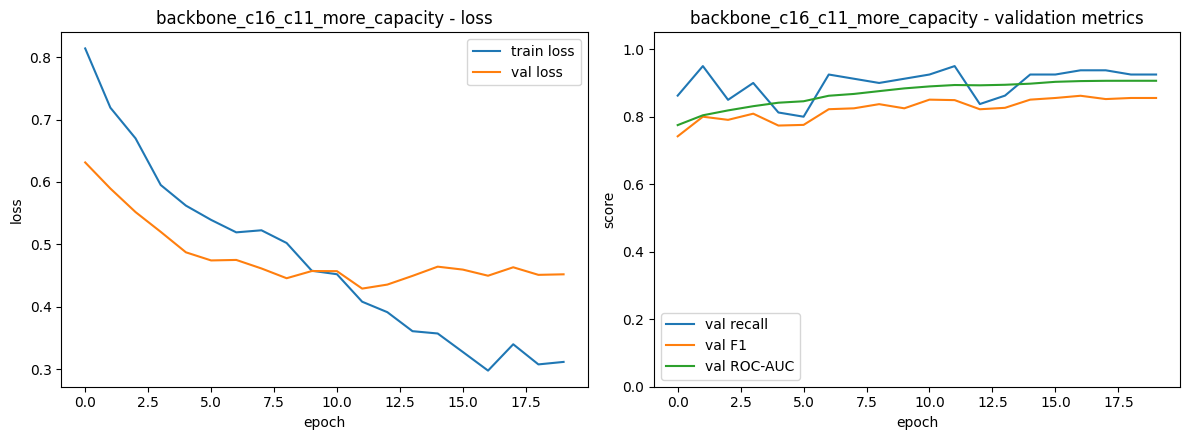

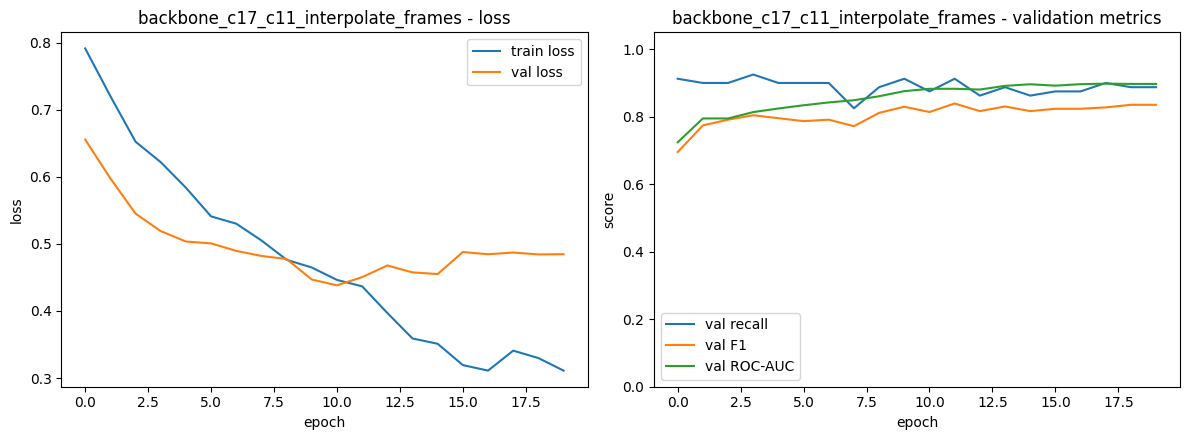

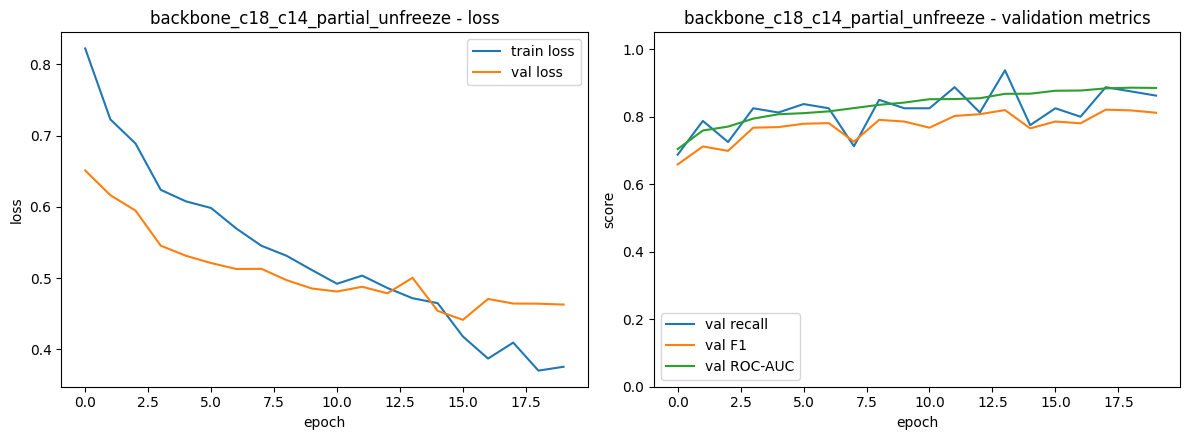

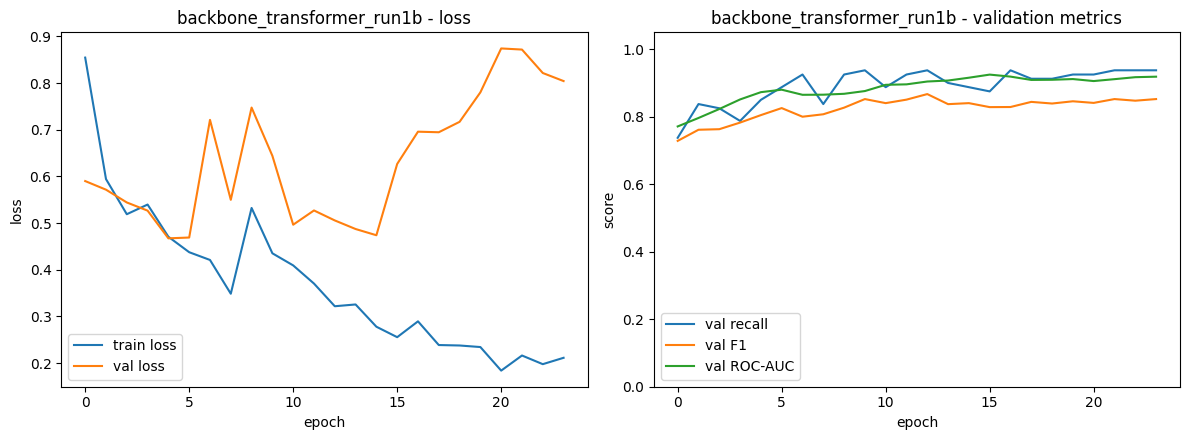

In [35]:
RUNS_TO_PLOT = [name for name, _ in EXPERIMENTS]

baseline_history_path = Path(HISTORY_LOG_DIR) / BASELINE_RUN_NAME / "history.jsonl"
if baseline_history_path.exists():
    RUNS_TO_PLOT = RUNS_TO_PLOT + [BASELINE_RUN_NAME]
else:
    print(f"No baseline history at {baseline_history_path}, plotting the six new configs only.")


def load_histories(names):
    loaded = {}
    for name in names:
        history_path = Path(HISTORY_LOG_DIR) / name / "history.jsonl"
        if not history_path.exists():
            print(f"Skipping {name}: no history file at {history_path}")
            continue
        loaded[name] = read_history_file(history_path)
    return loaded


histories = load_histories(RUNS_TO_PLOT)
for name, records in histories.items():
    plot_training_curves(records, title=name)

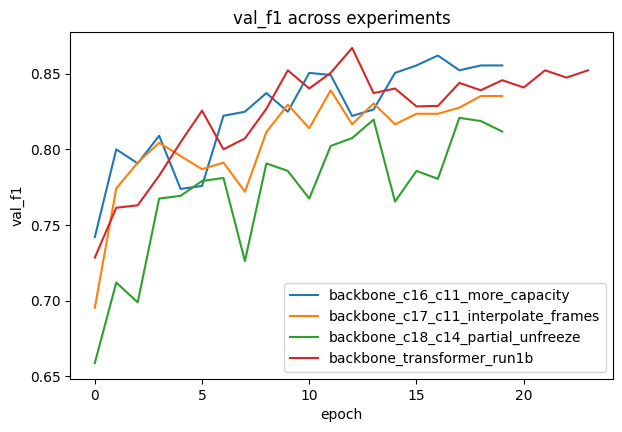

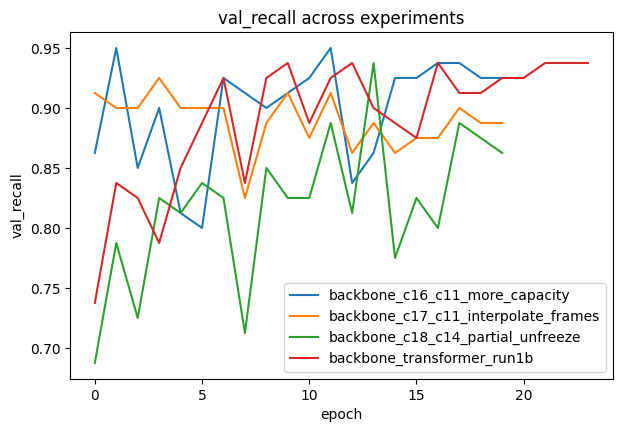

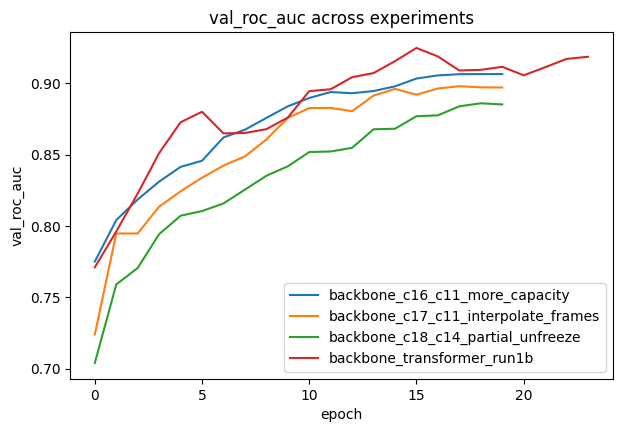

In [36]:
for metric_key in ["val_f1", "val_recall", "val_roc_auc"]:
    plot_comparison(histories, metric_key=metric_key)

## 6. Validation and test evaluation

Reloads each run's `best.pt` and evaluates it on both the validation split (the
one it was selected on) and the held-out test split, at the default threshold
0.5. The val-to-test gap here is the main overfitting signal this whole sweep is
about: a config that shrinks that gap without giving up much test performance is
the one that is actually fixing the problem, not just moving it around.

In [37]:
CHECKPOINT_FILE = "best.pt"
EVAL_BATCH_SIZE = 16

RUNS_TO_EVALUATE = [name for name, _ in EXPERIMENTS]
if baseline_history_path.exists() and (Path(CHECKPOINT_DIR) / BASELINE_RUN_NAME / CHECKPOINT_FILE).exists():
    RUNS_TO_EVALUATE = RUNS_TO_EVALUATE + [BASELINE_RUN_NAME]
else:
    print(f"No local baseline checkpoint at checkpoints/{BASELINE_RUN_NAME}/{CHECKPOINT_FILE}, "
          "evaluating the six new configs only.")


def load_run_for_evaluation(name):
    checkpoint_path = Path(CHECKPOINT_DIR) / name / CHECKPOINT_FILE
    if not checkpoint_path.exists():
        return None
    stored = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    config = Config.from_dict(stored["config"])
    del stored
    config.data.num_workers = 0
    config.data.pin_memory = False
    config.training.batch_size = EVAL_BATCH_SIZE
    config.model.pretrained = False
    model = build_model(config).to(device)
    checkpoint_info = load_checkpoint(checkpoint_path, model, map_location=device)
    model.eval()
    _, val_loader, test_loader = build_dataloaders(config)
    return config, model, val_loader, test_loader, checkpoint_info


predictions = {}
evaluated_epoch = {}
for name in RUNS_TO_EVALUATE:
    print(f"\n{'=' * 20} {name} {'=' * 20}")
    loaded = load_run_for_evaluation(name)
    if loaded is None:
        print(f"  no checkpoint at checkpoints/{name}/{CHECKPOINT_FILE}, skipping")
        continue
    config, model, val_loader, test_loader, checkpoint_info = loaded
    y_val, p_val = run_inference(model, val_loader, device)
    y_test, p_test = run_inference(model, test_loader, device)
    predictions[name] = {"val": (y_val.astype(int), p_val), "test": (y_test.astype(int), p_test)}
    evaluated_epoch[name] = checkpoint_info["epoch"] + 1
    model = val_loader = test_loader = None
    gc.collect()
    torch.cuda.empty_cache()

DEFAULT_THRESHOLD = 0.5
summary_rows = []
for name, split_predictions in predictions.items():
    row = {"experiment": name, "epoch": evaluated_epoch[name]}
    for split_name in ("val", "test"):
        y_true, y_prob = split_predictions[split_name]
        metrics = compute_binary_metrics(y_true, y_prob, threshold=DEFAULT_THRESHOLD)
        for metric_name, value in metrics.items():
            row[f"{split_name}_{metric_name}"] = value
    row["val_test_f1_gap"] = row["val_f1"] - row["test_f1"]
    row["val_test_auc_gap"] = row["val_roc_auc"] - row["test_roc_auc"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("experiment")
display(summary_df.round(4))


==================== backbone_c16_c11_more_capacity ====================


/home/pp26/miniconda3/envs/pt/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:02<00:00,  2.49s/it]



==================== backbone_c17_c11_interpolate_frames ====================


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:06<00:00,  2.65s/it]



==================== backbone_c18_c14_partial_unfreeze ====================


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:00<00:00,  2.43s/it]



==================== backbone_transformer_run1b ====================


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:11<00:00,  2.86s/it]


,epoch,val_accuracy,val_precision,val_recall,val_f1,val_f2,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_f2,test_roc_auc,val_test_f1_gap,val_test_auc_gap
experiment,,,,,,,,,,,,,,,
backbone_c16_c11_more_capacity,19,0.8438,0.7957,0.925,0.8555,0.8959,0.9062,0.7975,0.8182,0.765,0.7907,0.7751,0.8902,0.0648,0.0161
backbone_c17_c11_interpolate_frames,18,0.8125,0.7660,0.900,0.8276,0.8696,0.8983,0.7950,0.8073,0.775,0.7908,0.7812,0.8892,0.0368,0.0091
backbone_c18_c14_partial_unfreeze,19,0.8062,0.7692,0.875,0.8187,0.8516,0.8850,0.8250,0.8155,0.840,0.8276,0.8350,0.9025,-0.0089,-0.0175
backbone_transformer_run1b,16,0.8188,0.7865,0.875,0.8284,0.8557,0.9253,0.7675,0.7831,0.740,0.7609,0.7482,0.8788,0.0675,0.0466


## 7. ROC curves and confusion matrices

ROC curves (validation and test) for every evaluated run on the same axes, then
one confusion matrix per run at the default threshold 0.5 (test split).

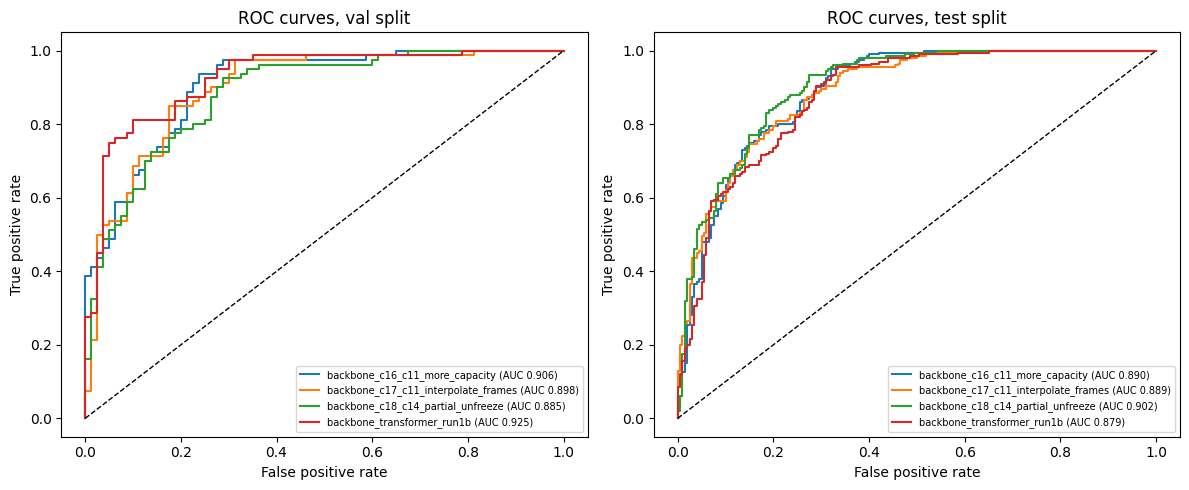

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, split_name in zip(axes, ("val", "test")):
    for name, split_predictions in predictions.items():
        y_true, y_prob = split_predictions[split_name]
        false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_prob)
        auc = compute_binary_metrics(y_true, y_prob)["roc_auc"]
        ax.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC {auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curves, {split_name} split")
    ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

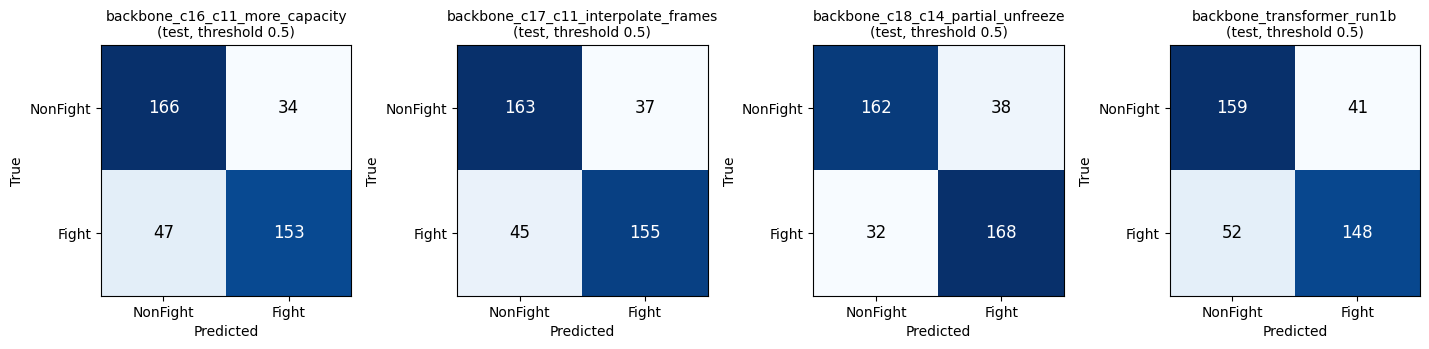

In [39]:
def draw_confusion_matrix(ax, matrix, labels, title):
    ax.imshow(matrix, cmap="Blues")
    for (row, column), value in np.ndenumerate(matrix):
        color = "white" if value > matrix.max() / 2 else "black"
        ax.text(column, row, str(value), ha="center", va="center", color=color, fontsize=12)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=10)


class_names = ("NonFight", "Fight")
number_of_runs = len(predictions)
fig, axes = plt.subplots(1, number_of_runs, figsize=(3.6 * number_of_runs, 3.8), squeeze=False)
for column_index, (name, split_predictions) in enumerate(predictions.items()):
    y_test, p_test = split_predictions["test"]
    matrix = compute_confusion_matrix(y_test, (p_test >= DEFAULT_THRESHOLD).astype(int))
    draw_confusion_matrix(axes[0, column_index], matrix, class_names, f"{name}\n(test, threshold 0.5)")
plt.tight_layout()
plt.show()

## 8. Threshold search

Same procedure as the main notebook: pick the threshold on validation that
reaches `TARGET_RECALL`, apply it to test. Shown per run so a config that looks
close to `B3` at the default 0.5 threshold but has more room to trade precision
for recall is visible here, not just in the section 6 table.

In [40]:
TARGET_RECALL = 0.95

threshold_results = {}
for name, split_predictions in predictions.items():
    y_val, p_val = split_predictions["val"]
    y_test, p_test = split_predictions["test"]
    chosen_threshold = find_threshold_for_recall(y_val, p_val, TARGET_RECALL)
    threshold_results[name] = {
        "threshold": chosen_threshold,
        "before": compute_binary_metrics(y_test, p_test, threshold=DEFAULT_THRESHOLD),
        "after": compute_binary_metrics(y_test, p_test, threshold=chosen_threshold),
    }

print(f"Test split, target recall {TARGET_RECALL} (threshold chosen on the validation split)")
print(f"{'experiment':<40}{'setting':<22}{'threshold':>10}{'precision':>10}{'recall':>8}{'f1':>8}")
for name, result in threshold_results.items():
    for setting, threshold, metrics in [
        ("default", DEFAULT_THRESHOLD, result["before"]),
        ("validation-selected", result["threshold"], result["after"]),
    ]:
        print(f"{name:<40}{setting:<22}{threshold:>10.4f}{metrics['precision']:>10.4f}"
              f"{metrics['recall']:>8.4f}{metrics['f1']:>8.4f}")
    print()

Test split, target recall 0.95 (threshold chosen on the validation split)
experiment                              setting                threshold precision  recall      f1
backbone_c16_c11_more_capacity          default                   0.5000    0.8182  0.7650  0.7907
backbone_c16_c11_more_capacity          validation-selected       0.3534    0.7882  0.8000  0.7940

backbone_c17_c11_interpolate_frames     default                   0.5000    0.8073  0.7750  0.7908
backbone_c17_c11_interpolate_frames     validation-selected       0.2300    0.7613  0.8450  0.8009

backbone_c18_c14_partial_unfreeze       default                   0.5000    0.8155  0.8400  0.8276
backbone_c18_c14_partial_unfreeze       validation-selected       0.2813    0.7699  0.9200  0.8383

backbone_transformer_run1b              default                   0.5000    0.7831  0.7400  0.7609
backbone_transformer_run1b              validation-selected       0.0423    0.7542  0.8900  0.8165



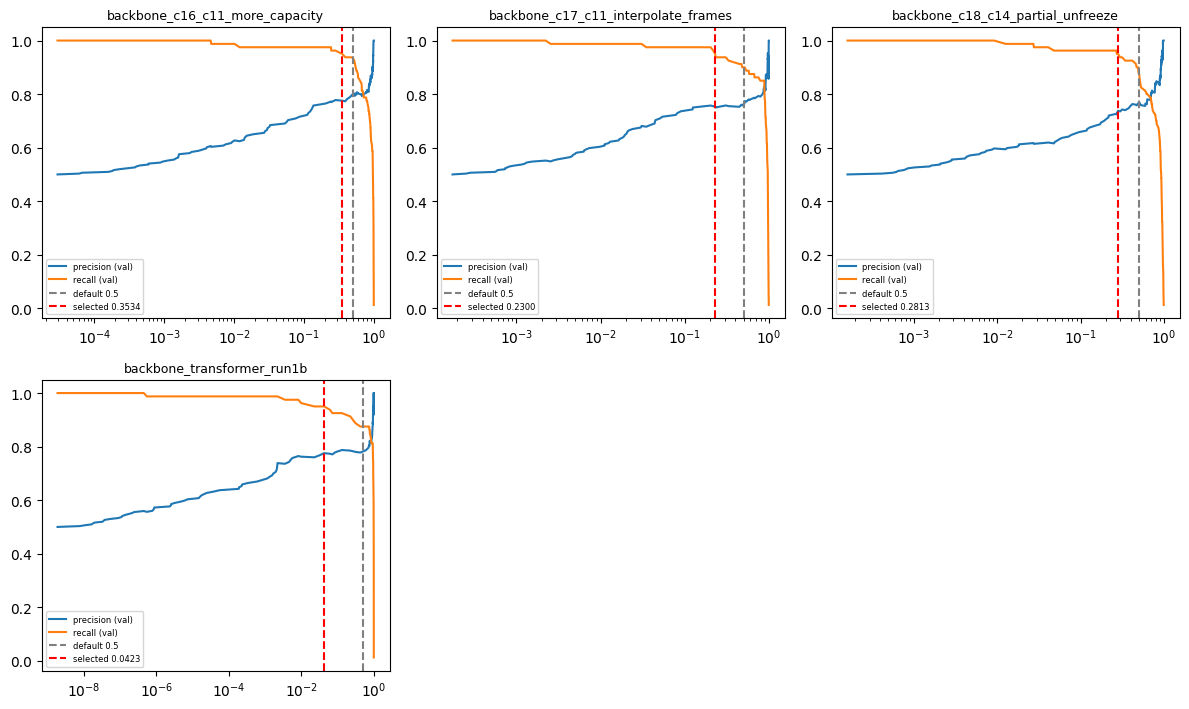

In [41]:
number_of_columns = 3
number_of_rows = math.ceil(len(predictions) / number_of_columns)
fig, axes = plt.subplots(number_of_rows, number_of_columns, figsize=(4 * number_of_columns, 3.6 * number_of_rows), squeeze=False)
axes = axes.ravel()
for ax, (name, split_predictions) in zip(axes, predictions.items()):
    y_val, p_val = split_predictions["val"]
    precision, recall, thresholds = precision_recall_curve(y_val, p_val)
    keep = thresholds > 0
    ax.plot(thresholds[keep], precision[:-1][keep], label="precision (val)")
    ax.plot(thresholds[keep], recall[:-1][keep], label="recall (val)")
    ax.axvline(DEFAULT_THRESHOLD, color="gray", linestyle="--", label="default 0.5")
    chosen = threshold_results[name]["threshold"]
    if chosen > 0:
        ax.axvline(chosen, color="red", linestyle="--", label=f"selected {chosen:.4f}")
    ax.set_xscale("log")
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=6, loc="lower left")
for ax in axes[len(predictions):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Summary: which configuration actually helps

Ranks every evaluated run by test ROC-AUC, and shows the val-to-test F1 gap next
to it. Look for a config that both keeps test performance close to (or above)
`B3` **and** has a visibly smaller val-to-test gap than `B3` (2.9 F1 points in the
original run, though the September rerun in the main notebook shows that number
itself is not fully stable run to run, so judge by direction and magnitude here,
not by matching a single fixed number). A config that shrinks the gap mainly
because *validation* performance also dropped is a sign it drifted toward
underfitting rather than fixing overfitting, worth checking against the training
curves in section 5 before trusting the gap number alone.

,epoch,val_f1,test_f1,val_test_f1_gap,val_roc_auc,test_roc_auc,val_test_auc_gap,test_recall
experiment,,,,,,,,
backbone_c18_c14_partial_unfreeze,19,0.8187,0.8276,-0.0089,0.8850,0.9025,-0.0175,0.840
backbone_c16_c11_more_capacity,19,0.8555,0.7907,0.0648,0.9062,0.8902,0.0161,0.765
backbone_c17_c11_interpolate_frames,18,0.8276,0.7908,0.0368,0.8983,0.8892,0.0091,0.775
backbone_transformer_run1b,16,0.8284,0.7609,0.0675,0.9253,0.8788,0.0466,0.740


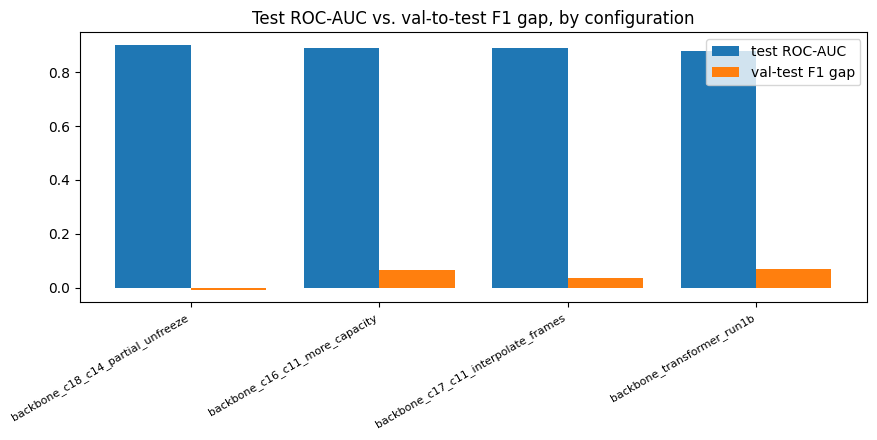

In [42]:
ranked = summary_df.sort_values("test_roc_auc", ascending=False)
display(ranked[["epoch", "val_f1", "test_f1", "val_test_f1_gap", "val_roc_auc", "test_roc_auc", "val_test_auc_gap", "test_recall"]].round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
x_positions = np.arange(len(ranked))
ax.bar(x_positions - 0.2, ranked["test_roc_auc"], width=0.4, label="test ROC-AUC")
ax.bar(x_positions + 0.2, ranked["val_test_f1_gap"], width=0.4, label="val-test F1 gap")
ax.set_xticks(x_positions)
ax.set_xticklabels(ranked.index, rotation=30, ha="right", fontsize=8)
ax.legend()
ax.set_title("Test ROC-AUC vs. val-to-test F1 gap, by configuration")
plt.tight_layout()
plt.show()